## Step 1 — Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)



## Step 2 — Create & Load Custom Data

We'll build a **House Price Prediction** dataset.

**Features:**
- `size_sqft` — Size of the house in square feet
- `num_bedrooms` — Number of bedrooms
- `age_years` — Age of the house in years
- `distance_city_km` — Distance from city center (km)

**Target:** `price_usd` — House price in USD

In [12]:
n_samples = 300
size_sqft        = np.random.randint(600, 4000, n_samples).astype(float)
num_bedrooms     = np.random.randint(1, 6, n_samples).astype(float)
age_years        = np.random.randint(1, 50, n_samples).astype(float)
distance_city_km = np.random.uniform(1, 40, n_samples)

price_usd = (
    150 * size_sqft
    + 8000  * num_bedrooms
    - 1500  * age_years
    - 3000  * distance_city_km
    + 50000                         
    + np.random.normal(0, 25000, n_samples)
)

price_usd = np.clip(price_usd, 50000, None)

df = pd.DataFrame({
    'size_sqft':        size_sqft,
    'num_bedrooms':     num_bedrooms,
    'age_years':        age_years,
    'distance_city_km': distance_city_km,
    'price_usd':        price_usd
})

print(f'Dataset shape: {df.shape}')
df.head(10)

Dataset shape: (300, 5)


,size_sqft,num_bedrooms,age_years,distance_city_km,price_usd
0,3624.0,5.0,47.0,17.413650,505762.396523
1,1760.0,2.0,35.0,8.710910,260700.702331
2,857.0,4.0,34.0,38.685041,56621.303833
3,2256.0,2.0,18.0,13.587335,349012.109383
4,2390.0,5.0,11.0,16.182467,383561.588043
5,3522.0,3.0,27.0,4.377547,565096.651152
6,3014.0,5.0,11.0,3.487320,498584.978844
7,1020.0,3.0,4.0,16.388193,166836.788407
8,639.0,4.0,47.0,19.996163,50000.000000
9,2178.0,2.0,16.0,35.125808,268270.687649


---
## 🔍 Step 3 — Exploratory Data Analysis (EDA)

In [ ]:
print('=== Dataset Info ===')
df.info()
print('\n=== Descriptive Statistics ===')
df.describe().round(2)

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   size_sqft         300 non-null    float64
 1   num_bedrooms      300 non-null    float64
 2   age_years         300 non-null    float64
 3   distance_city_km  300 non-null    float64
 4   price_usd         300 non-null    float64
dtypes: float64(5)
memory usage: 11.8 KB

=== Descriptive Statistics ===


,size_sqft,num_bedrooms,age_years,distance_city_km,price_usd
count,300.00,300.00,300.00,300.00,300.00
mean,2276.85,3.16,25.06,21.03,316556.67
std,1015.22,1.45,14.11,11.43,156241.32
min,614.00,1.00,1.00,1.00,50000.00
25%,1378.50,2.00,12.00,10.77,183759.87
50%,2245.50,3.00,25.00,22.50,317078.59
75%,3218.25,4.00,38.00,31.14,440392.63
max,3998.00,5.00,49.00,39.96,678902.16


In [ ]:
missing = df.isnull().sum()
print('Missing values per column:')
print(missing)
print(f'\nTotal missing: {missing.sum()}')

Missing values per column:
size_sqft           0
num_bedrooms        0
age_years           0
distance_city_km    0
price_usd           0
dtype: int64

Total missing: 0


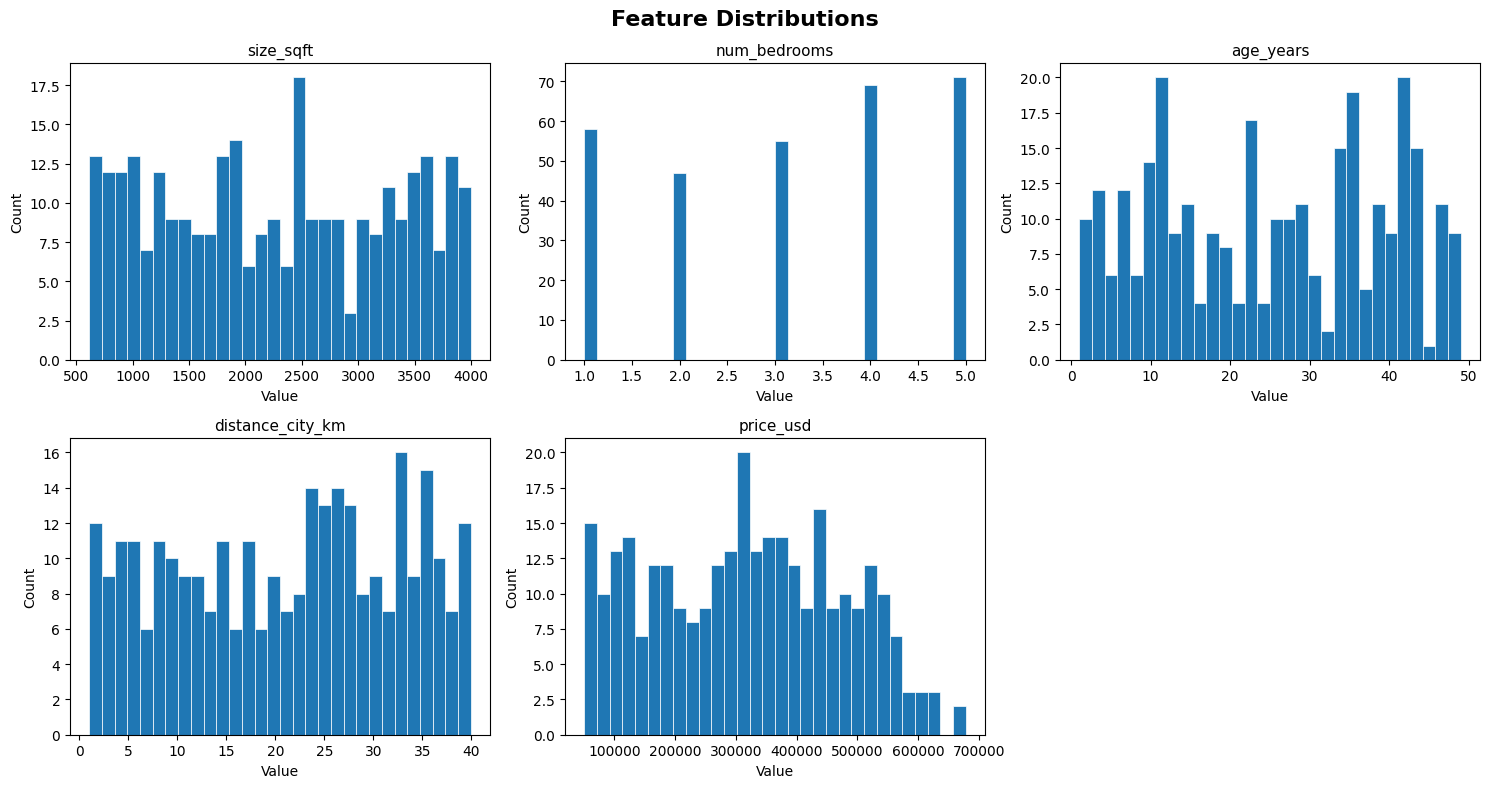

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Feature Distributions', fontsize=16, fontweight='bold')

columns = df.columns.tolist()
for idx, col in enumerate(columns):
    ax = axes[idx // 3][idx % 3]
    ax.hist(df[col], bins=30, edgecolor='white', linewidth=0.5)
    ax.set_title(col, fontsize=11)
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')

axes[1][2].set_visible(False)

plt.tight_layout()
plt.show()


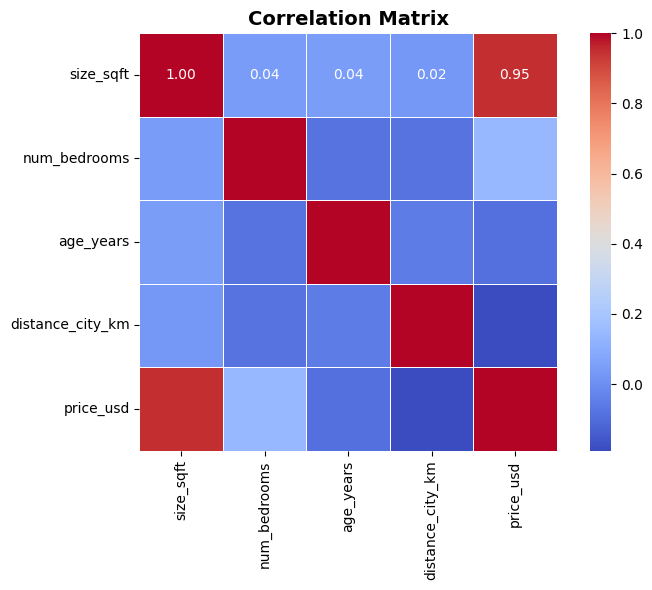

In [ ]:
plt.figure(figsize=(8, 6))
corr_matrix = df.corr()
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    square=True,
    linewidths=0.5
)
plt.title('Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

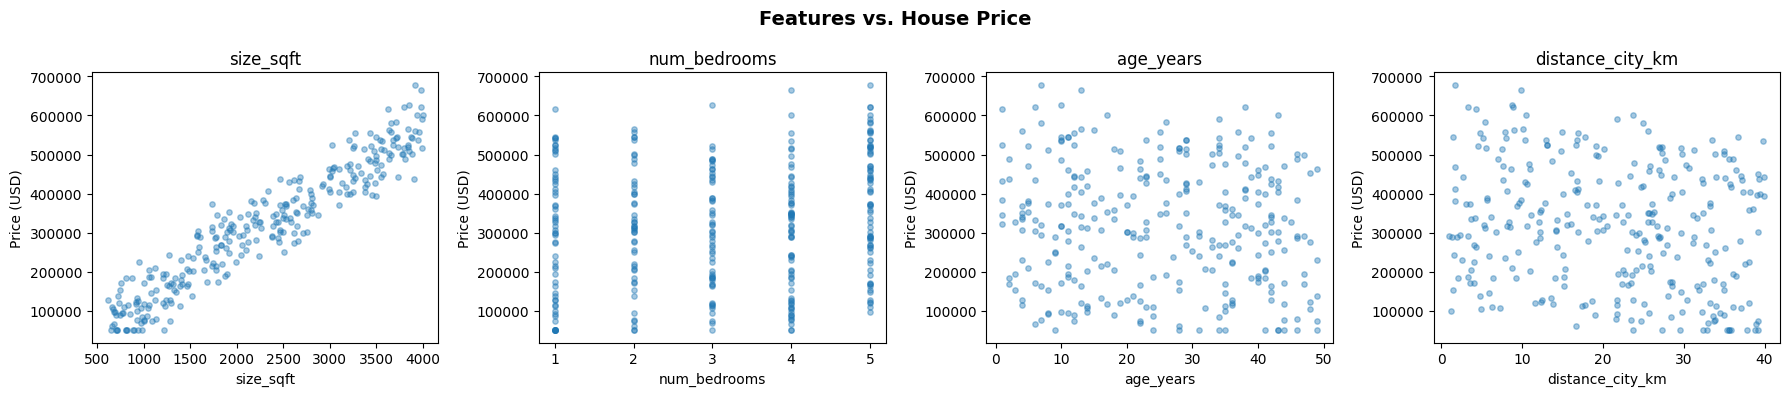

In [ ]:
features = ['size_sqft', 'num_bedrooms', 'age_years', 'distance_city_km']

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle('Features vs. House Price', fontsize=14, fontweight='bold')

for ax, feat in zip(axes, features):
    ax.scatter(df[feat], df['price_usd'], alpha=0.4, s=15)
    ax.set_xlabel(feat)
    ax.set_ylabel('Price (USD)')
    ax.set_title(f'{feat}')

plt.tight_layout()
plt.show()

## Step 4 — Data Preprocessing

Before training:
- **Split** into train / test sets
- **Scale** features with `StandardScaler` (zero mean, unit variance)

In [ ]:
feature_cols = ['size_sqft', 'num_bedrooms', 'age_years', 'distance_city_km']

X = df[feature_cols]
y = df['price_usd']

print(f'Features shape: {X.shape}')
print(f'Target shape:   {y.shape}')

Features shape: (300, 4)
Target shape:   (300,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f'Training set:   {X_train.shape[0]} samples')
print(f'Test set:       {X_test.shape[0]} samples')

Training set:   240 samples
Test set:       60 samples


In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)  
X_test_scaled  = scaler.transform(X_test)       

print('Scaler mean (per feature):')
for feat, mean in zip(feature_cols, scaler.mean_):
    print(f'  {feat:<22}: {mean:.2f}')


Scaler mean (per feature):
  size_sqft             : 2292.00
  num_bedrooms          : 3.08
  age_years             : 25.27
  distance_city_km      : 21.71


## Step 5 — Train the Linear Regression Model

**Linear Regression** models the relationship:

$$\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \ldots + \beta_n x_n$$

It minimises **Mean Squared Error (MSE)** using Ordinary Least Squares (OLS).

In [13]:
model = LinearRegression(
    fit_intercept=True   
)

model.fit(X_train_scaled, y_train)

print(f'\nIntercept (β₀):  {model.intercept_:,.2f}')
print('\nCoefficients:')
for feat, coef in zip(feature_cols, model.coef_):
    print(f'  {feat:<22}: {coef:>12,.2f}')


Intercept (β₀):  315,865.44

Coefficients:
  size_sqft             :   154,098.26
  num_bedrooms          :    12,366.22
  age_years             :   -19,227.97
  distance_city_km      :   -33,762.20


## Step 6 — Evaluate the Model

| Metric | Formula | Interpretation |
|--------|---------|----------------|
| **MAE** | mean\|y - ŷ\| | Average absolute error (in dollars) |
| **MSE** | mean(y - ŷ)² | Penalises large errors more |
| **RMSE** | √MSE | Same unit as target |
| **R²** | 1 - SS_res/SS_tot | 1 = perfect, 0 = baseline |

In [15]:
y_train_pred = model.predict(X_train_scaled)
y_test_pred  = model.predict(X_test_scaled)

def evaluate(y_true, y_pred, label=''):
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred)
    print(f'--- {label} ---')
    print(f'  MAE  : ${mae:>12,.2f}')
    print(f'  MSE  : ${mse:>12,.2f}')
    print(f'  RMSE : ${rmse:>12,.2f}')
    print(f'  R²   : {r2:>13.4f}')
    return {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2}

train_metrics = evaluate(y_train, y_train_pred, 'TRAIN SET')
print()
test_metrics  = evaluate(y_test,  y_test_pred,  'TEST SET')

--- TRAIN SET ---
  MAE  : $   17,978.91
  MSE  : $520,354,359.37
  RMSE : $   22,811.28
  R²   :        0.9794

--- TEST SET ---
  MAE  : $   21,138.29
  MSE  : $698,925,165.63
  RMSE : $   26,437.19
  R²   :        0.9660


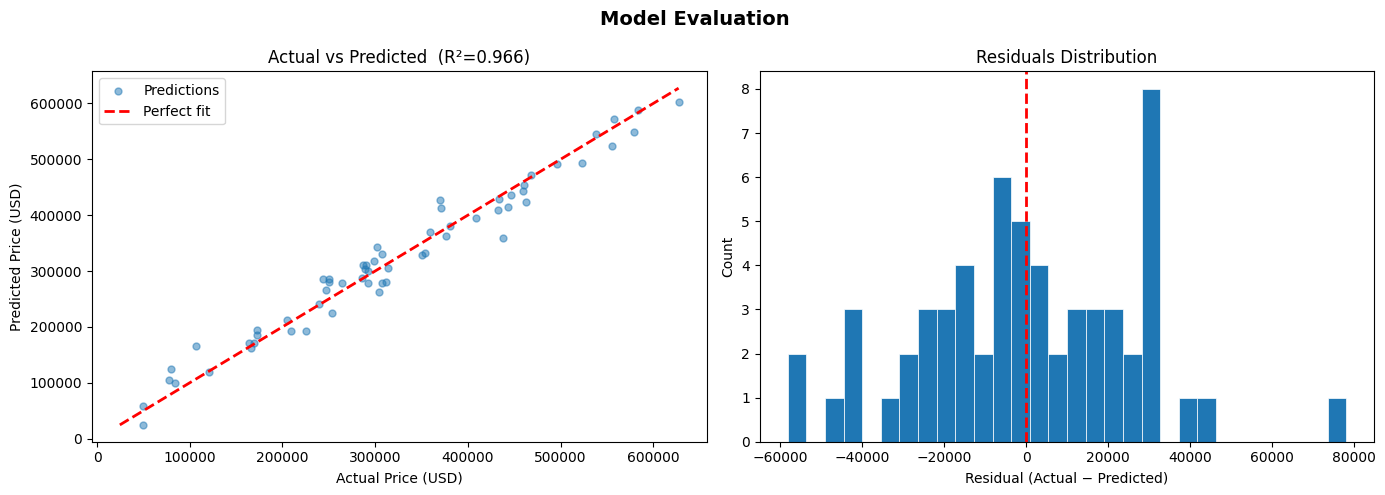

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model Evaluation', fontsize=14, fontweight='bold')

ax1 = axes[0]
ax1.scatter(y_test, y_test_pred, alpha=0.5, s=25, label='Predictions')
min_val = min(y_test.min(), y_test_pred.min())
max_val = max(y_test.max(), y_test_pred.max())
ax1.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect fit')
ax1.set_xlabel('Actual Price (USD)')
ax1.set_ylabel('Predicted Price (USD)')
ax1.set_title(f'Actual vs Predicted  (R²={test_metrics["R2"]:.3f})')
ax1.legend()

ax2 = axes[1]
residuals = y_test - y_test_pred
ax2.hist(residuals, bins=30, edgecolor='white', linewidth=0.5)
ax2.axvline(x=0, color='red', linestyle='--', lw=2)
ax2.set_xlabel('Residual (Actual − Predicted)')
ax2.set_ylabel('Count')
ax2.set_title('Residuals Distribution')

plt.tight_layout()
plt.show()

## Step 7 — Save the Model

Two popular methods:

| Method | Best for | Notes |
|--------|----------|-------|
| **`joblib`** | sklearn models | Faster for large numpy arrays |
| **`pickle`** | general Python objects | Slightly more universal |

In [17]:
import joblib
import pickle
import os

In [19]:
# ── Method 1: Save with joblib (RECOMMENDED for sklearn) ─────────────────────
os.makedirs('saved_models', exist_ok=True)

model_path  = 'saved_models/linear_regression.joblib'
scaler_path = 'saved_models/scaler.joblib'

joblib.dump(model,  model_path)
joblib.dump(scaler, scaler_path)

model_size = os.path.getsize(model_path)
print(f'Model  saved → {model_path}  ({model_size} bytes)')
print(f'Scaler saved → {scaler_path}')

Model  saved → saved_models/linear_regression.joblib  (633 bytes)
Scaler saved → saved_models/scaler.joblib


In [20]:
# ── Method 2: Save with pickle ───────────────────────────────────────────────
pickle_path = 'saved_models/linear_regression.pkl'

with open(pickle_path, 'wb') as f:
    pickle.dump(model, f)

print(f'Model saved (pickle) → {pickle_path}')

print('\nSaved files:')
for fname in os.listdir('saved_models'):
    size = os.path.getsize(f'saved_models/{fname}')
    print(f'  {fname:<40} {size} bytes')

Model saved (pickle) → saved_models/linear_regression.pkl

Saved files:
  linear_regression.joblib                 633 bytes
  linear_regression.pkl                    483 bytes
  scaler.joblib                            1015 bytes


## Step 8 — Load the Saved Model 

This simulates using your saved model in a **production environment** or a new session.

In [21]:
# ── Load model and scaler from disk ──────────────────────────────────────────
loaded_model  = joblib.load('saved_models/linear_regression.joblib')
loaded_scaler = joblib.load('saved_models/scaler.joblib')

print(f'Model type  : {type(loaded_model).__name__}')
print(f'Scaler type : {type(loaded_scaler).__name__}')

Model type  : LinearRegression
Scaler type : StandardScaler
